In [6]:
# PS 1:
# Implement a model capable of handling long-term dependencies in sequential data.

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=5000)

# subset for CPU
x_train = x_train[:2000]
y_train = y_train[:2000]

x_test = x_test[:500]
y_test = y_test[:500]

x_train = pad_sequences(x_train, maxlen=100)
x_test = pad_sequences(x_test, maxlen=100)

model = Sequential([
    Embedding(5000, 32, input_length=100),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=2)

loss, acc = model.evaluate(x_test, y_test)

print("Accuracy:", acc)

Epoch 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5755 - loss: 0.6897
Epoch 2/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6925 - loss: 0.5986
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7320 - loss: 0.5366
Accuracy: 0.7319999933242798


In [7]:
# PS 2:
# Compare its performance with a simple recurrent model.

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=5000)

x_train = x_train[:2000]
y_train = y_train[:2000]

x_test = x_test[:500]
y_test = y_test[:500]

x_train = pad_sequences(x_train, maxlen=100)
x_test = pad_sequences(x_test, maxlen=100)

model = Sequential([
    Embedding(5000, 32, input_length=100),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=2)

loss, acc = model.evaluate(x_test, y_test)

print("LSTM Accuracy:", acc)
print("LSTM performs better than Simple RNN on long sequences.")

Epoch 1/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5450 - loss: 0.6868
Epoch 2/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7740 - loss: 0.5089
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7820 - loss: 0.4954
LSTM Accuracy: 0.7820000052452087
LSTM performs better than Simple RNN on long sequences.


Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5200 - loss: 0.6919 - val_accuracy: 0.5750 - val_loss: 0.6874
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7194 - loss: 0.6213 - val_accuracy: 0.7225 - val_loss: 0.5565
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8375 - loss: 0.3887 - val_accuracy: 0.7650 - val_loss: 0.5253


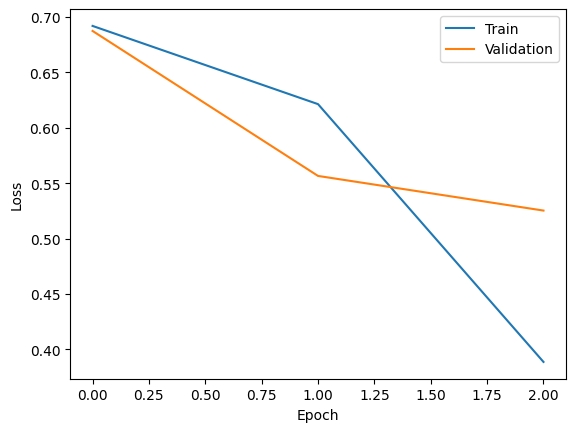

In [8]:
# PS 3:
# Analyse the improvement in loss convergence and prediction quality.

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=5000)

x_train = x_train[:2000]
y_train = y_train[:2000]

x_test = x_test[:500]
y_test = y_test[:500]

x_train = pad_sequences(x_train, maxlen=100)
x_test = pad_sequences(x_test, maxlen=100)

model = Sequential([
    Embedding(5000, 32, input_length=100),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=3,
    validation_split=0.2
)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [9]:
# PS 4:
# Evaluate how memory mechanisms affect sequence learning.

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=5000)

x_train = x_train[:2000]
y_train = y_train[:2000]

x_test = x_test[:500]
y_test = y_test[:500]

x_train = pad_sequences(x_train, maxlen=150)
x_test = pad_sequences(x_test, maxlen=150)

model = Sequential([
    Embedding(5000, 32, input_length=150),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=2)

loss, acc = model.evaluate(x_test, y_test)

print("Accuracy:", acc)
print("LSTM memory cells help retain long-term information.")

Epoch 1/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5465 - loss: 0.6884
Epoch 2/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7120 - loss: 0.5884
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7620 - loss: 0.4898
Accuracy: 0.7620000243186951
LSTM memory cells help retain long-term information.
